# Romberg ML Model - Data Preprocessing
## 1. Starter Data
- num of (unique) samples with eyes open: 8
  
  num of non-unique samples: 2
- num of (unique) samples with eyes closed: 8

  num of non-unique samples: 2

so the dataset created will have ten rows

In [ ]:
!rm -rf sophia-romberg-data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1a. Data Collection:
TODO: Set up script that pulls all new CSV files from a repo/set of repos

Data format:
(https://drive.google.com/drive/folders/1GeIZo_ZzwndkKTcrNOfdFyAkFWzRBl_h?usp=sharing)

/ data

      / 0
          / session_0
              eyes_open.csv
              eyes_closed.csv
              Metadata.csv
          / session_1
              eyes_open.csv
              eyes_closed.csv
              Metadata.csv
          ...
          / session_n
      
      / 1
          / session_0
              eyes_open.csv
              eyes_closed.csv
              Metadata.csv
      ...
      / n


The actual CSV files **should all follow the same naming convention of `Metadata.csv`, `eyes_open.csv` and `eyes_closed.csv` respectively**. Also please title folders accordingly to make things easier.

Repeating multiple sessions with the same subject will not lead to a different label (as it is assumed that a person either always fails or passes the test). But it will give us more training data (rows in the dataset).

This allows the script to just look into each folder in the directory, go through the session folders, and pull the correct CSV files.

## 2. Preprocessing Steps
- set label as `closed` or `open` for each data point depending on the file name. this will be the label for the rows.
- add unique `session_id` corresponding to **each recording session.**
- add a column for `subject_id` for who the data was recorded from (don't use actual names for privacy reasons, instead use integer naming like 0, 1, 2, 3, etc)
- add columns for computed duration of eyes open and closed
- add column for the label, ie 'stable' or 'impaired' -- will need to one-hot encode this later
- compute some stats from the accelerometer stats for eyes open/closed

Proposed data columns:
- `session_id`
- `subject_id`
- `label`
- `eyes_open_duration`
- `eyes_closed_duration`
- `rms_open`, `rms_closed`
- `std_mag_open`, `std_mag_closed`
- `romberg_ratio_rms`
- `romberg_ratio_std`

Note: some of these features can be removed later but it's better to start with more features in the beginning. I used this chatGPT conversation for figuring out some features to use: https://chatgpt.com/share/69bed09c-0c84-8012-a8da-42470ea86154

An interesting article on the use of the Romberg ratio: https://www.sciencedirect.com/science/article/pii/S0966636214007905

## 3. Training
- train/test/valid split: 70/20/10
- IMPORTANT: split data by subject, not session

In [ ]:
!git clone https://github.com/A2AppRom/sophia-romberg-data

Cloning into 'sophia-romberg-data'...
remote: Enumerating objects: 102, done.
remote: Counting objects: 100% (102/102), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 102 (delta 19), reused 73 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (102/102), 4.65 MiB | 20.08 MiB/s, done.
Resolving deltas: 100% (19/19), done.


In [ ]:
import os
import pandas as pd
import numpy as np
from scipy.stats import kurtosis, skew

In [ ]:
ROOT = '/content/drive/MyDrive/cs410/cs410_project/data'
subjects = os.listdir(ROOT)

In [ ]:
subjects

['subject_1',
 'subject_2',
 'subject_3',
 'subject_4',
 'subject_0',
 'subject_5',
 'subject_6',
 'subject_7',
 'subject_8',
 'subject_10',
 'subject_11',
 'subject_12',
 'subject_13',
 'subject_14',
 'subject_15',
 'subject_16',
 'subject_17',
 'subject_18',
 'subject_19',
 'subject_20',
 'subject_21',
 'subject_9']

In [ ]:
cols = ['subject_id', 'session_id', 'label', 'duration', 'mean', 'median',
        'std', 'skew', 'kurtosis']

In [ ]:
df = pd.DataFrame(columns=cols)

In [ ]:
!rm -rf .DS_Store

In [ ]:
def extract_windows(df, label, subject_id, session_id, window_size=200, step=100):
    df['mag'] = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2)
    rows = []
    for start in range(0, len(df) - window_size, step):
        window = df['mag'].iloc[start:start+window_size]
        wx = df['x'].iloc[start:start+window_size]
        wy = df['y'].iloc[start:start+window_size]
        wz = df['z'].iloc[start:start+window_size]
        rows.append({
            'subject_id': subject_id,
            'session_id': session_id,
            'label': label,
            # magnitude features
            'mean': window.mean(),
            'std': window.std(),
            'skew': skew(window),
            'kurtosis': kurtosis(window),
            #'iqr': iqr(window),
            #'zcr': (np.diff(np.sign(window - window.mean())) != 0).sum() / window_size,
            # per-axis std
            #'std_x': wx.std(), 'std_y': wy.std(), 'std_z': wz.std(),
            # cross-axis correlation
            #'corr_xy': wx.corr(wy), 'corr_xz': wx.corr(wz), 'corr_yz': wy.corr(wz),
            # frequency
            #'dominant_freq': np.fft.rfftfreq(window_size)[np.argmax(np.abs(np.fft.rfft(window)))],
            #'spectral_entropy': (lambda p: -np.sum(p * np.log(p + 1e-10)))(
                #np.abs(np.fft.rfft(window))**2 / (np.sum(np.abs(np.fft.rfft(window))**2) + 1e-10)
            #),
        })
    return rows

In [ ]:
for i in range (len(subjects)):
  sub_path = os.path.join(ROOT, subjects[i])
  sessions = os.listdir(sub_path)

  for j in range(len(sessions)):
    session = os.path.join(sub_path, sessions[j])

    open = pd.read_csv(os.path.join(session, 'eyes_open.csv'))
    closed = pd.read_csv(os.path.join(session, 'eyes_closed.csv'))

    open = extract_windows(open, 'open', subjects[i][8:], sessions[j][8:])
    closed = extract_windows(closed, 'closed', subjects[i][8:], sessions[j][8:])

    df = pd.concat([df, pd.DataFrame(open)], ignore_index=True)
    df = pd.concat([df, pd.DataFrame(closed)], ignore_index=True)
df

/tmp/ipykernel_15183/279744932.py:14: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, pd.DataFrame(open)], ignore_index=True)


,subject_id,session_id,label,duration,mean,median,std,skew,kurtosis
0,1,0,open,NaN,0.909995,NaN,0.846551,1.301782,1.352531
1,1,0,open,NaN,0.310538,NaN,0.383275,2.821215,8.335592
2,1,0,open,NaN,0.145016,NaN,0.083381,1.207825,2.140250
3,1,0,open,NaN,0.124378,NaN,0.053487,1.030937,2.011242
4,1,0,open,NaN,0.121274,NaN,0.053172,1.212680,2.589167
...,...,...,...,...,...,...,...,...,...
4129,9,0,closed,NaN,0.068248,NaN,0.031727,0.814021,0.673043
4130,9,0,closed,NaN,0.079317,NaN,0.037407,0.460965,-0.451617
4131,9,0,closed,NaN,0.088547,NaN,0.048806,0.937236,1.327940
4132,9,0,closed,NaN,0.322572,NaN,0.293195,0.927721,-0.172657


In [ ]:
df = df.drop(columns="median")

In [ ]:
df.head()

,subject_id,session_id,label,mean,std,skew,kurtosis
0,1,0,open,0.909995,0.846551,1.301782,1.352531
1,1,0,open,0.310538,0.383275,2.821215,8.335592
2,1,0,open,0.145016,0.083381,1.207825,2.140250
3,1,0,open,0.124378,0.053487,1.030937,2.011242
4,1,0,open,0.121274,0.053172,1.212680,2.589167


old method without sliding window to get more features

In [ ]:
for i in range (len(subjects)):
  sub_path = os.path.join(ROOT, subjects[i])
  sessions = os.listdir(sub_path)

  for j in range(len(sessions)):
    session = os.path.join(sub_path, sessions[j])

    open = pd.read_csv(os.path.join(session, 'eyes_open.csv'))
    closed = pd.read_csv(os.path.join(session, 'eyes_closed.csv'))

    open_time_diff = open['time'].iloc[-1] - open['time'].iloc[0]
    closed_time_diff = closed['time'].iloc[-1] - closed['time'].iloc[0]

    open['mag'] = np.sqrt(open['x']**2 + open['y']**2 + open['z']**2)
    closed['mag'] = np.sqrt(closed['x']**2 + closed['y']**2 + closed['z']**2)

    mean_open = np.mean(open['mag'])
    mean_closed = np.mean(closed['mag'])

    median_open = np.median(open['mag'])
    median_closed = np.median(closed['mag'])

    std_open = np.std(open['mag'])
    std_closed = np.std(closed['mag'])

    skew_open = skew(open['mag'])
    skew_closed = skew(closed['mag'])

    kurtosis_open = kurtosis(open['mag'])
    kurtosis_closed = kurtosis(closed['mag'])

    # add data with eyes open label
    df_temp_open = pd.DataFrame(columns=cols)
    df_temp_open.loc[len(df_temp_open)] = {"label": "open",
                                 "session_id": sessions[j][8:],
                                 "subject_id": subjects[i][8:],
                                 "duration": open_time_diff,
                                 "mean": mean_open,"median": median_open,
                                 "std": std_open, "skew": skew_open,
                                           "kurtosis": kurtosis_open}

    df = pd.concat([df, df_temp_open], ignore_index=True)

    # add data with eyes closed label
    df_temp_closed = pd.DataFrame(columns=cols)
    df_temp_closed.loc[len(df_temp_closed)] = {"label": "closed", "session_id": sessions[j][8:],
                                 "subject_id": subjects[i][8:],
                                 "duration": closed_time_diff,
                                 "mean": mean_closed,"median": median_closed,
                                 "std": std_closed, "skew": skew_closed,
                                           "kurtosis": kurtosis_closed}

    df = pd.concat([df, df_temp_closed], ignore_index=True)
df


/tmp/ipykernel_11179/4269844989.py:42: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, df_temp_open], ignore_index=True)


,subject_id,session_id,label,duration,mean,median,std,skew,kurtosis
0,1,0,open,58251602400,0.121713,0.060539,0.334678,9.272823,133.034741
1,1,0,closed,45065531600,0.183694,0.104852,0.318721,5.781224,42.265251
2,2,0,open,42344970200,0.134327,0.073325,0.247356,5.967011,43.137762
3,2,0,closed,42567076100,0.128552,0.082975,0.226567,7.675751,75.174710
4,3,0,open,42296806700,0.118685,0.071725,0.216500,7.366179,71.688904
...,...,...,...,...,...,...,...,...,...
129,21,21,closed,24587150600,0.127059,0.117015,0.061733,0.953016,1.405858
130,21,22,open,25086958200,0.080192,0.068274,0.048288,1.366182,2.126001
131,21,22,closed,25088583500,0.136727,0.128369,0.064094,0.757398,0.718660
132,9,0,open,34484737800,0.130125,0.091172,0.129116,2.997391,10.527108


In [ ]:
df.to_csv("labeled_data_with_features_FINAL1.csv")

feature engineering
- generate plots to understand the data:
  - scatter plot of rms and label

In [ ]:
df['duration']

,duration
0,58251602400
1,45065531600
2,42344970200
3,42567076100
4,42296806700
...,...
129,24587150600
130,25086958200
131,25088583500
132,34484737800


In [ ]:
cols

['subject_id',
 'session_id',
 'label',
 'duration',
 'rms',
 'std_mag',
 'romberg_ratio_rms',
 'romberg_ratio_std']

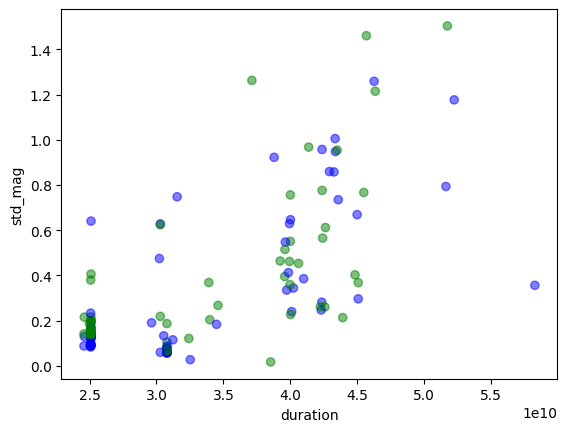

In [ ]:
import matplotlib.pyplot as plt

colors = {'open': 'blue', 'closed': 'green'}
# Create a list of colors based on the group column
color_list = [colors[g] for g in df['label']]
plt.scatter(df['duration'], df['rms'], c=color_list, alpha=0.5)
plt.xlabel('duration')
plt.ylabel('std_mag')
plt.show()